# Minh Mệnh — Hán OCR config spike (PaddleOCR 3.x / PP-OCRv5)

**Mục tiêu:** trang 149 mất hẳn cột nội dung `諭曰朕嗣服云初每欲與大小庶官夙夜咸勤期于`, trang 147 (bìa 卷之五) OCR fail (1 box conf 0.083). Kiểm tra config `pipeline/config.py` (`SINONOM` + `PREPROCESS`) có phải thủ phạm không, sweep vài config trên vài trang, chọn config đọc đủ mọi cột để align với tiếng Việt.

## 2 nghi phạm chính
1. **Downscale khi detect.** PP-OCRv5 mặc định giới hạn cạnh ảnh (`text_det_limit_side_len`, `limit_type='max'`). Trang xoay 90° ~2480px cạnh dài → bị thu nhỏ → cột đậm dày dính/mất. → nâng `text_det_limit_side_len` ≥ cạnh dài, hoặc `limit_type='min'`.
2. **Preprocess `binarize="adaptive"`** (block 31, C 15) + denoise: trên nét mộc bản đậm dễ ăn mòn/vỡ nét → recognizer nhả cột. Bạn test PaddleOCR **raw** (không preprocess) nên đọc được → nghi preprocess.

> ⚠️ Config bạn gợi ý (`det_db_box_thresh 0.45→0.55`, `det_db_thresh 0.25→0.35`) là **PaddleOCR 2.x** và **nâng ngưỡng = detect CHẶT hơn = ÍT box hơn**. Bài này lỗi là **THIẾU cột (under-detect)** → cần NỚI ngưỡng (thấp hơn), ngược hướng. Sweep dưới test cả 2 chiều để dữ liệu tự quyết.


## Param 2.x → 3.x (PP-OCRv5)
| 2.x (bạn đưa) | 3.x (dùng ở đây) | mặc định | ghi chú |
|---|---|---|---|
| `use_angle_cls` | `use_textline_orientation` | False | ta tự xoay cả trang → để False |
| `det_db_thresh` | `text_det_thresh` | 0.30 | nhị phân prob-map; thấp = bắt nét mờ |
| `det_db_box_thresh` | `text_det_box_thresh` | 0.60 | điểm box tối thiểu; **thấp = bắt cột yếu** |
| `det_db_unclip_ratio` | `text_det_unclip_ratio` | 1.50 | phình box; cao = nối chữ trong cột, quá cao = dính cột cạnh |
| `det_limit_side_len` | `text_det_limit_side_len` | 736/960 | **thủ phạm downscale** |
| — | `text_det_limit_type` | 'max' | 'max'=cap cạnh dài (downscale ảnh lớn); 'min'=cap cạnh ngắn (không thu nhỏ) |

3.x cho truyền các param này ở **constructor** `PaddleOCR(...)` và/hoặc override ở `.predict(img, ...)`.


In [1]:
# === Colab install (bỏ comment khi chạy Colab GPU) ===
!pip install paddlepaddle-gpu==3.3.1 -i https://www.paddlepaddle.org.cn/packages/stable/cu129/
!pip install paddleocr

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu129/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 GB 661.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.4/781.4 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 580.7/580.7 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.8/331.8 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.4/366.4 MB 759.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# === FIX ImportError torch/nccl (undefined symbol: ncclDevCommCreate) ===
# paddleocr -> paddlex official_models.py:33 -> `import modelscope` (VÔ ĐIỀU KIỆN)
# -> modelscope/logger.py:48 thấy find_spec('torch') != None -> `import torch` -> chết (nccl lệch).
# OCR KHÔNG dùng torch. Gỡ torch => modelscope bỏ nhánh torch => import sạch.
# PHẢI chạy TRƯỚC 'import paddleocr'. (torch chưa import thành công nên khỏi restart.)
!pip uninstall -y torch torchvision torchaudio


Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [1]:
import paddleocr, inspect
print('paddleocr', paddleocr.__version__)
# In ra param detect thực có trong build này (tên có thể drift giữa các bản 3.x)
sig = inspect.signature(paddleocr.PaddleOCR.__init__)
det_params = [n for n in sig.parameters if any(k in n.lower() for k in
              ['det','thresh','unclip','limit','side','orient','rec_'])]
print('detect/recog params:', det_params)


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


paddleocr 3.7.0
detect/recog params: ['doc_orientation_classify_model_name', 'doc_orientation_classify_model_dir', 'text_detection_model_name', 'text_detection_model_dir', 'textline_orientation_model_name', 'textline_orientation_model_dir', 'textline_orientation_batch_size', 'use_doc_orientation_classify', 'use_textline_orientation', 'text_det_limit_side_len', 'text_det_limit_type', 'text_det_thresh', 'text_det_box_thresh', 'text_det_unclip_ratio', 'text_det_input_shape', 'text_rec_score_thresh', 'text_rec_input_shape']


## Đưa ảnh trang lên — **Cách 2: upload tay** (đang bật)
Ảnh KHÔNG nằm trong git (`.gitignore`: `output*/`, `ocr_zips/*`). Trên Colab đĩa rỗng → phải đưa lên.

**Cách 2 (mặc định):** chạy cell dưới → hiện nút *Choose Files* → kéo thả các PNG (`page_0149.png`, `page_0147.png`, `page_0150.png`, `page_0151.png`). Lấy từ máy bạn: `ocr_zips/vol2/pages_han/`.

Cách 1 (Drive+unzip) và Cách 3 (local) để sẵn dạng comment ở cell kế nếu sau cần.


In [2]:
import cv2, numpy as np, statistics
from pathlib import Path
import matplotlib.pyplot as plt

VOL = 'vol2'
# trang test: 149 = mất cột, 147 = bìa fail, 150/151 = trang thường (regression)
TEST_PAGES = [149, 147, 150, 151]
TARGET_SNIPPET = '嗣服'   # thuộc cột 諭曰朕嗣服云初... (mất ở 149) -> check config cứu được


In [3]:
# === CÁCH 2 (upload tay vài PNG) — ĐANG BẬT ===
# Chạy cell -> nút 'Choose Files' hiện ra -> kéo thả các PNG cần:
#   page_0149.png, page_0147.png, page_0150.png, page_0151.png (đúng TEST_PAGES).
# Lấy PNG từ máy bạn ở: ocr_zips/vol2/pages_han/  (hoặc output_p1/vol2/pages_han/)
from google.colab import files
up = files.upload()                       # blocking tới khi upload xong
PAGES_DIR = Path('/content/manual'); PAGES_DIR.mkdir(exist_ok=True)
for fn in list(up):                       # gom file đã upload vào PAGES_DIR
    Path(fn).rename(PAGES_DIR/Path(fn).name)
print('PAGES_DIR =', PAGES_DIR, '| đã có:', sorted(p.name for p in PAGES_DIR.glob('*.png')))


Saving page_0147.png to page_0147.png
Saving page_0149.png to page_0149.png
Saving page_0150.png to page_0150.png
Saving page_0151.png to page_0151.png
Saving page_0152.png to page_0152.png
Saving page_0153.png to page_0153.png
Saving page_0154.png to page_0154.png
Saving page_0155.png to page_0155.png
Saving page_0156.png to page_0156.png
PAGES_DIR = /content/manual | đã có: ['page_0147.png', 'page_0149.png', 'page_0150.png', 'page_0151.png', 'page_0152.png', 'page_0153.png', 'page_0154.png', 'page_0155.png', 'page_0156.png', 'page_0225.png', 'page_0227.png', 'page_0228.png', 'page_0229.png', 'page_0230.png', 'page_0231.png', 'page_0232.png', 'page_0233.png', 'page_0234.png', 'page_0235.png', 'page_0236.png', 'page_0237.png', 'page_0238.png', 'page_0239.png', 'page_0240.png', 'page_0241.png', 'page_0242.png', 'page_0243.png', 'page_0244.png', 'page_0245.png', 'page_0246.png', 'page_0247.png', 'page_0248.png', 'page_0249.png', 'page_0250.png', 'page_0251.png', 'page_0252.png', 'page_02

In [6]:
# === CÁCH 1 (Drive + unzip) — tắt; bỏ comment nếu muốn dùng Drive ===
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE = '/content/drive/MyDrive/minh_menh'
# ZIP = f'{DRIVE}/output_p1/{VOL}.zip'        # hoặc f'{DRIVE}/ocr_zips/{VOL}.zip'
# !mkdir -p /content/work && unzip -oq '{ZIP}' -d /content/work
# cands = list(Path('/content/work').rglob('pages_han'))
# PAGES_DIR = cands[0] if cands else Path(f'/content/work/{VOL}/pages_han')
# print('PAGES_DIR =', PAGES_DIR, '| tồn tại:', PAGES_DIR.exists())

# === CÁCH 3 (chạy LOCAL từ gốc repo) — tắt ===
# REPO = Path('.')
# PAGES_DIR = REPO/'ocr_zips'/VOL/'pages_han'
# if not PAGES_DIR.exists(): PAGES_DIR = REPO/'output_p1'/VOL/'pages_han'


In [4]:
# --- kiểm tra chung (chạy sau khi đã upload xong ở cách 2) ---
assert PAGES_DIR.exists(), f'không thấy pages_han: {PAGES_DIR}'
missing = [p for p in TEST_PAGES if not (PAGES_DIR/f'page_{p:04d}.png').exists()]
assert not missing, f'thiếu ảnh trang: {missing}'
print('OK — pages_dir', PAGES_DIR, '| test', TEST_PAGES)


OK — pages_dir /content/manual | test [149, 147, 150, 151]


In [5]:
# --- preprocess giống pipeline (để so raw vs adaptive vs otsu) ---
def preprocess(bgr, binarize='adaptive', denoise=True, deskew=False):
    img = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if bgr.ndim==3 else bgr
    if denoise:
        img = cv2.fastNlMeansDenoising(img, h=10)
    if binarize=='otsu':
        _,img = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    elif binarize=='adaptive':
        img = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,31,15)
    return img

def load_rotated(page, binarize=None, denoise=False):
    """đọc trang, (tuỳ chọn) preprocess, xoay 90° CCW (cột dọc RTL -> dòng ngang LTR)."""
    p = PAGES_DIR/f'page_{page:04d}.png'
    bgr = cv2.imread(str(p)); assert bgr is not None, p
    if binarize is not None or denoise:
        pre = preprocess(bgr, binarize=binarize, denoise=denoise)
        bgr = cv2.cvtColor(pre, cv2.COLOR_GRAY2BGR) if pre.ndim==2 else pre
    rot = cv2.rotate(bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return bgr, rot


In [6]:
# --- runner: build 1 PaddleOCR / config, predict, trả detections ---
BASE = dict(lang='chinese_cht', use_doc_orientation_classify=False,
            use_doc_unwarping=False, use_textline_orientation=False)

_cache = {}
def get_ocr(**kw):
    key = tuple(sorted(kw.items()))
    if key not in _cache:
        from paddleocr import PaddleOCR
        _cache[key] = PaddleOCR(**{**BASE, **kw})
    return _cache[key]

def predict(ocr, img):
    res = ocr.predict(img)
    if not res: return []
    r = res[0]
    def g(k):
        try: return r[k]
        except Exception: return getattr(r, k, None)
    texts = g('rec_texts') or []; scores = g('rec_scores') or []
    polys = g('rec_polys'); polys = g('dt_polys') if polys is None else polys
    if polys is None: return []
    out=[]
    for poly,t,s in zip(polys,texts,scores):
        xs=[float(pt[0]) for pt in poly]; ys=[float(pt[1]) for pt in poly]
        out.append(dict(bbox=(min(xs),min(ys),max(xs),max(ys)), text=t, conf=float(s)))
    return out

def n_columns(dets, tol_frac=0.55):
    """đếm cột: cụm detection theo x-centre (trên ảnh ĐÃ XOAY, x-centre ~ vị trí cột)."""
    if not dets: return 0
    cx = sorted(( (d['bbox'][0]+d['bbox'][2])/2 for d in dets))
    wm = statistics.median([d['bbox'][2]-d['bbox'][0] for d in dets]) or 1
    cols=1
    for a,b in zip(cx, cx[1:]):
        if b-a > tol_frac*wm: cols+=1
    return cols


In [7]:
# === Ma trận config để sweep ===
# NB: tên param det có thể khác giữa bản 3.x -> nếu constructor báo lỗi tên,
#     xem list in ở cell trên rồi sửa cho khớp.
LONG_SIDE = 2560   # >= cạnh dài trang xoay (~2480) => KHÔNG downscale

CONFIGS = {
  'baseline (project: server + adaptive)': dict(
        ocr=dict(text_detection_model_name='PP-OCRv5_server_det',
                 text_recognition_model_name='PP-OCRv5_server_rec'),
        pre=dict(binarize='adaptive', denoise=True)),
  'raw img (no preprocess)': dict(
        ocr=dict(text_detection_model_name='PP-OCRv5_server_det',
                 text_recognition_model_name='PP-OCRv5_server_rec'),
        pre=dict(binarize=None, denoise=False)),
  'no-downscale (limit_side 2560)': dict(
        ocr=dict(text_detection_model_name='PP-OCRv5_server_det',
                 text_recognition_model_name='PP-OCRv5_server_rec',
                 text_det_limit_side_len=LONG_SIDE, text_det_limit_type='max'),
        pre=dict(binarize=None, denoise=False)),
  'sensitive det (box_thresh .3, unclip 2.0)': dict(
        ocr=dict(text_detection_model_name='PP-OCRv5_server_det',
                 text_recognition_model_name='PP-OCRv5_server_rec',
                 text_det_limit_side_len=LONG_SIDE, text_det_limit_type='max',
                 text_det_thresh=0.30, text_det_box_thresh=0.30, text_det_unclip_ratio=2.0),
        pre=dict(binarize=None, denoise=False)),
  'user-suggested (strict, 3.x-mapped)': dict(
        ocr=dict(text_detection_model_name='PP-OCRv5_server_det',
                 text_recognition_model_name='PP-OCRv5_server_rec',
                 text_det_limit_side_len=2000, text_det_limit_type='max',
                 text_det_thresh=0.35, text_det_box_thresh=0.55, text_det_unclip_ratio=1.6),
        pre=dict(binarize=None, denoise=False)),
}


In [8]:
# === chạy sweep: đếm cột + có cứu được cột mục tiêu không ===
import pandas as pd
rows=[]
det_store={}
for name,cfg in CONFIGS.items():
    try:
        ocr = get_ocr(**cfg['ocr'])
    except (ValueError, TypeError) as e:
        print(f'[skip] {name}: constructor từ chối param -> {e}'); continue
    for pg in TEST_PAGES:
        _, rot = load_rotated(pg, **cfg['pre'])
        dets = predict(ocr, rot)
        det_store[(name,pg)] = (rot, dets)
        alltxt = ''.join(d['text'] for d in dets)
        rows.append(dict(config=name, page=pg, n_det=len(dets),
                         n_cols=n_columns(dets),
                         has_target=(TARGET_SNIPPET in alltxt) if pg==149 else None,
                         mean_conf=round(statistics.mean([d['conf'] for d in dets]),3) if dets else 0))
df = pd.DataFrame(rows)
display(df.pivot_table(index='config', columns='page', values='n_cols', sort=False))
print('\ncó cột mục tiêu (trang 149)?')
display(df[df.page==149][['config','n_det','n_cols','has_target','mean_conf']])


/tmp/ipykernel_5731/365730761.py:10: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  _cache[key] = PaddleOCR(**{**BASE, **kw})
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not be

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None, None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

/tmp/ipykernel_5731/365730761.py:10: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  _cache[key] = PaddleOCR(**{**BASE, **kw})
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_rec`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_

page,149,147,150,151
config,,,,
baseline (project: server + adaptive),2.0,4.0,2.0,1.0
raw img (no preprocess),2.0,5.0,4.0,1.0
no-downscale (limit_side 2560),2.0,5.0,4.0,1.0
"sensitive det (box_thresh .3, unclip 2.0)",2.0,15.0,4.0,1.0
"user-suggested (strict, 3.x-mapped)",2.0,10.0,2.0,1.0



có cột mục tiêu (trang 149)?


,config,n_det,n_cols,has_target,mean_conf
0,baseline (project: server + adaptive),9,2,False,0.788
4,raw img (no preprocess),11,2,True,0.827
8,no-downscale (limit_side 2560),11,2,True,0.827
12,"sensitive det (box_thresh .3, unclip 2.0)",11,2,True,0.807
16,"user-suggested (strict, 3.x-mapped)",11,2,True,0.752


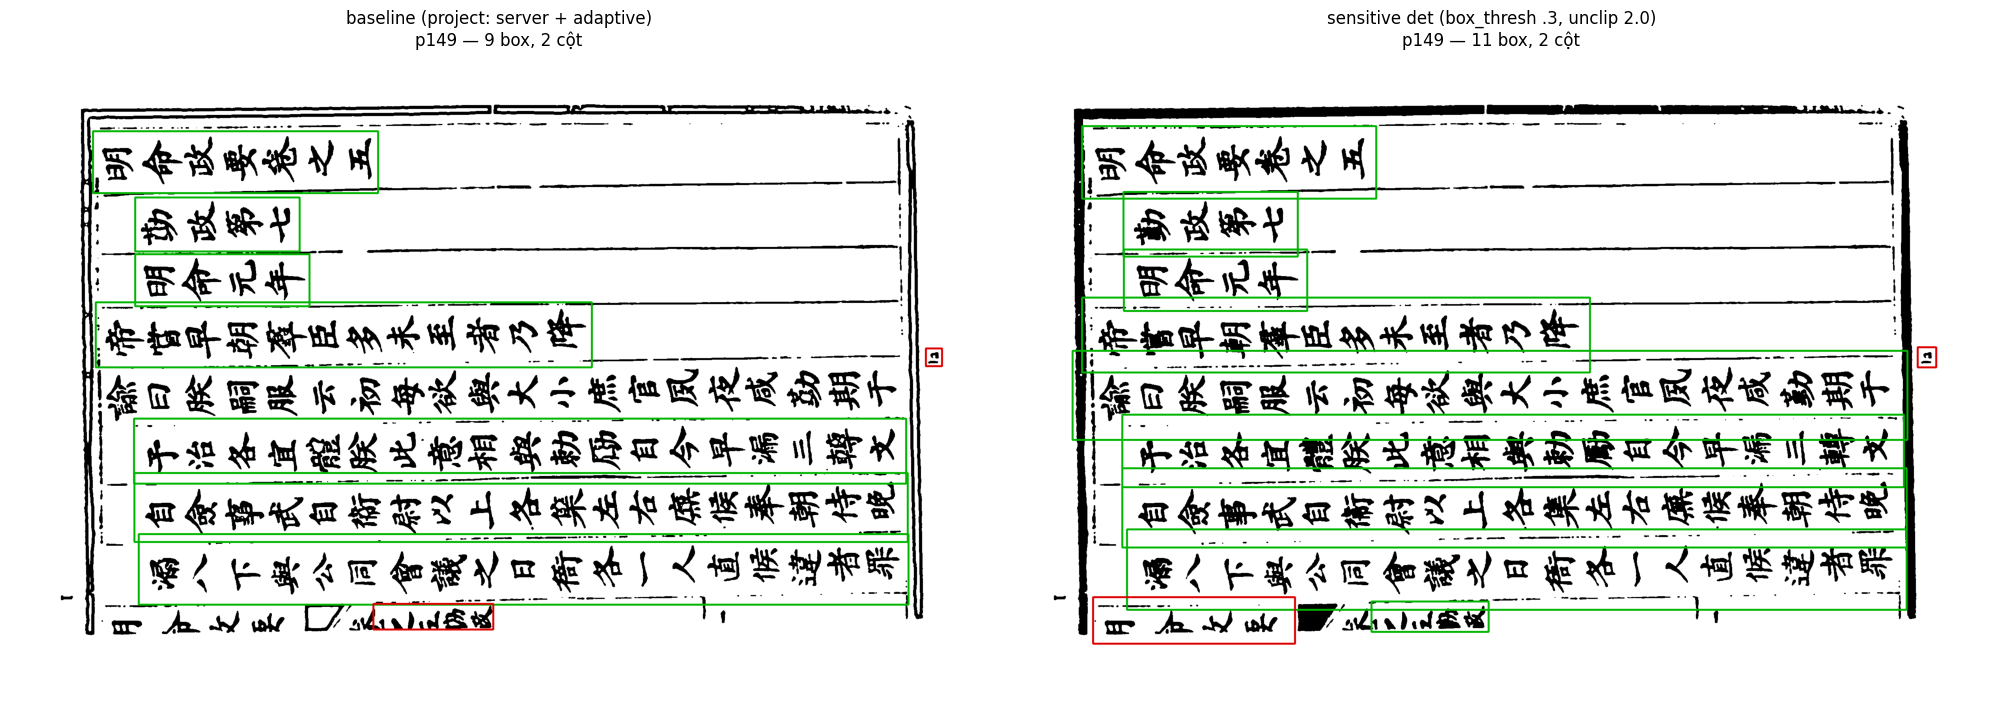

In [9]:
# === vẽ overlay: baseline vs config tốt nhất, trên trang 149 ===
def show(name, pg, ax):
    rot, dets = det_store[(name,pg)]
    vis = cv2.cvtColor(rot, cv2.COLOR_BGR2RGB).copy()
    for d in dets:
        x0,y0,x1,y1 = map(int, d['bbox'])
        c = (0,180,0) if d['conf']>0.5 else (220,0,0)
        cv2.rectangle(vis,(x0,y0),(x1,y1),c,3)
    ax.imshow(vis); ax.set_title(f'{name}\np{pg} — {len(dets)} box, {n_columns(dets)} cột'); ax.axis('off')

pairs = [('baseline (project: server + adaptive)',149),
         ('sensitive det (box_thresh .3, unclip 2.0)',149)]
fig,axes = plt.subplots(1,2,figsize=(20,14))
for ax,(nm,pg) in zip(axes,pairs):
    if (nm,pg) in det_store: show(nm,pg,ax)
plt.tight_layout(); plt.show()


## Kết luận & config đề xuất (điền sau khi chạy)

Đọc bảng `n_cols` trên: trang 149 **phải ra ≥ 8 cột** và `has_target=True`. Config nào đạt + `mean_conf` cao nhất → chọn.

**Giả thuyết (chờ số liệu xác nhận):**
- Tắt preprocess (`binarize=None`) + `text_det_limit_side_len=2560, limit_type='max'` cứu cột mất.
- Nếu vẫn thiếu → hạ `text_det_box_thresh` xuống ~0.3 + `text_det_unclip_ratio` ~2.0.
- Config bạn đưa (strict) dự kiến ra **ít cột hơn** — sai hướng cho lỗi thiếu cột.

**Khi chốt, sửa `pipeline/config.py`:**
```python
# PREPROCESS: cân nhắc binarize=None hoặc 'otsu' cho mộc bản đậm
PREPROCESS = dict(grayscale=True, deskew=True, denoise=False, binarize=None, upscale_min_height=0)

# SINONOM: thêm param detect (đưa vào _make_ocr trong step3_sinonom.py)
#   text_det_limit_side_len=2560, text_det_limit_type='max',
#   text_det_box_thresh=<giá trị thắng>, text_det_unclip_ratio=<giá trị thắng>
```
rồi vá `_make_ocr()` để truyền các param này vào `PaddleOCR(...)`.
